# 12-Autoencoders & Latent Space

Every architecture we have built so far (CNNs, ViTs, Faster R-CNN) has been **Discriminative**. We gave the network an image ($X$) and a human-provided label ($Y$). The network's only job was to learn the mathematical mapping from $X \rightarrow Y$.

But what if we don't have human labels? What if we just have 10 million images of the moon, and we want the network to fundamentally understand the physical structure of a crater?

We must use an **Autoencoder**, a neural network trained to copy its input to its output ($X \rightarrow \hat{X}$). By violently choking the architecture in the middle, we force the network to discover the hidden, mathematical rules of the dataset.

Let's set up our PyTorch environment to map the Latent Space.

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from skimage import data
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Autoencoder Environment Ready.")

✅ PyTorch Autoencoder Environment Ready.


# 1. The Architecture of Information Compression

If we simply connected a massive input layer directly to a massive output layer, the network would perfectly learn the Identity Function ($f(x) = x$). It would memorize the pixels without actually learning anything about the underlying geometry.

To prevent this, an Autoencoder consists of three distinct mathematical components:

1. **The Encoder ($\mathcal{E}$)**: A stack of Convolutions and Pooling layers that takes the high-dimensional input $X$ and aggressively downsamples it.
2. **The Bottleneck ($Z$)**: A severely restricted layer in the exact center of the network. This forces a massive dimensionality reduction.
3. **The Decoder ($\mathcal{D}$)**: A stack of Transpose Convolutions (upsampling) that takes the compressed data and attempts to mathematically blow it back up to the original image dimensions: $\hat{X} = \mathcal{D}(\mathcal{E}(X))$.

# 2. The Mathematics of Latent Space ($Z$)

The Bottleneck produces a vector called $Z$, which exists in a mathematical realm called the **Latent Space**.

Imagine an input image of $128 \times 128$ pixels. That is a $16,384$-dimensional matrix. If we restrict our bottleneck $Z$ to exactly 64 neurons, we are mathematically forcing the Encoder to compress $16,384$ raw physical numbers down into just $64$ highly abstract numbers.

To survive this violent compression and still allow the Decoder to rebuild the moon, the network cannot simply memorize pixel coordinates. It must mathematically deduce the **latent variables** (the underlying physical laws of the image).

* Neuron 1 in the $Z$-vector might naturally learn to represent "Crater Depth."
* Neuron 2 might represent "Lighting Angle."
* Neuron 3 might represent "Surface Albedo (Reflectivity)."

### The Manifold Hypothesis

In mathematics, the Manifold Hypothesis states that high-dimensional real-world data actually lies on a low-dimensional topological manifold embedded within that high-dimensional space. While a moon image has 16,384 pixels, the true degrees of freedom (the actual variance between different moon photos) is incredibly small. The Autoencoder's job is to unroll that manifold and map it into the $Z$ vector.

# 3. The Reconstruction Loss Function

Because we do not have human labels, the Autoencoder acts as its own supervisor. The input $x$ is both the training data and the target label.

To calculate how well the Decoder rebuilt the image, we use **Mean Squared Error (MSE)** to calculate the physical pixel deviation between the original matrix and the generated matrix:


$$L_{MSE}(X, \hat{X}) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2$$

During Backpropagation, the network calculates the gradient of the pixel errors, pushes it backward through the Decoder to fix the rebuilding process, and then through the Encoder to fix the compression process.

# 4. Engineering Application: Denoising Autoencoders (DAE)

Why would an enterprise build a network that just outputs what you put into it?

One of the most powerful applications of this architecture is the **Denoising Autoencoder**.
During training, we intentionally corrupt the input image by adding severe Gaussian noise to the matrix ($\tilde{X} = X + \epsilon$).
However, we calculate the MSE Loss against the **original, clean image**.

$$L_{Denoise} = ||X - \mathcal{D}(\mathcal{E}(\tilde{X}))||^2$$

Because random static noise has no mathematical pattern, it is physically impossible for the Encoder to compress the noise into the tiny 64-neuron bottleneck. The network is forced to act as an algorithmic filter—stripping away the static and only passing the true structural "signal" through the bottleneck.

# 5. Architecting an Autoencoder in PyTorch

Let's build an Enterprise-grade Convolutional Autoencoder. We will inject extreme Gaussian noise into our crisp photograph of the moon, mathematically compress it down into a tiny Latent Vector, and pass it to the Decoder.

Original Input Shape: torch.Size([1, 1, 128, 128]) (16,384 pixels)
--- 🧠 Executing the Autoencoder Pipeline ---
Latent Vector (Z) Shape: torch.Size([1, 64]) (Just 64 numbers!)
Reconstructed Shape:     torch.Size([1, 1, 128, 128])


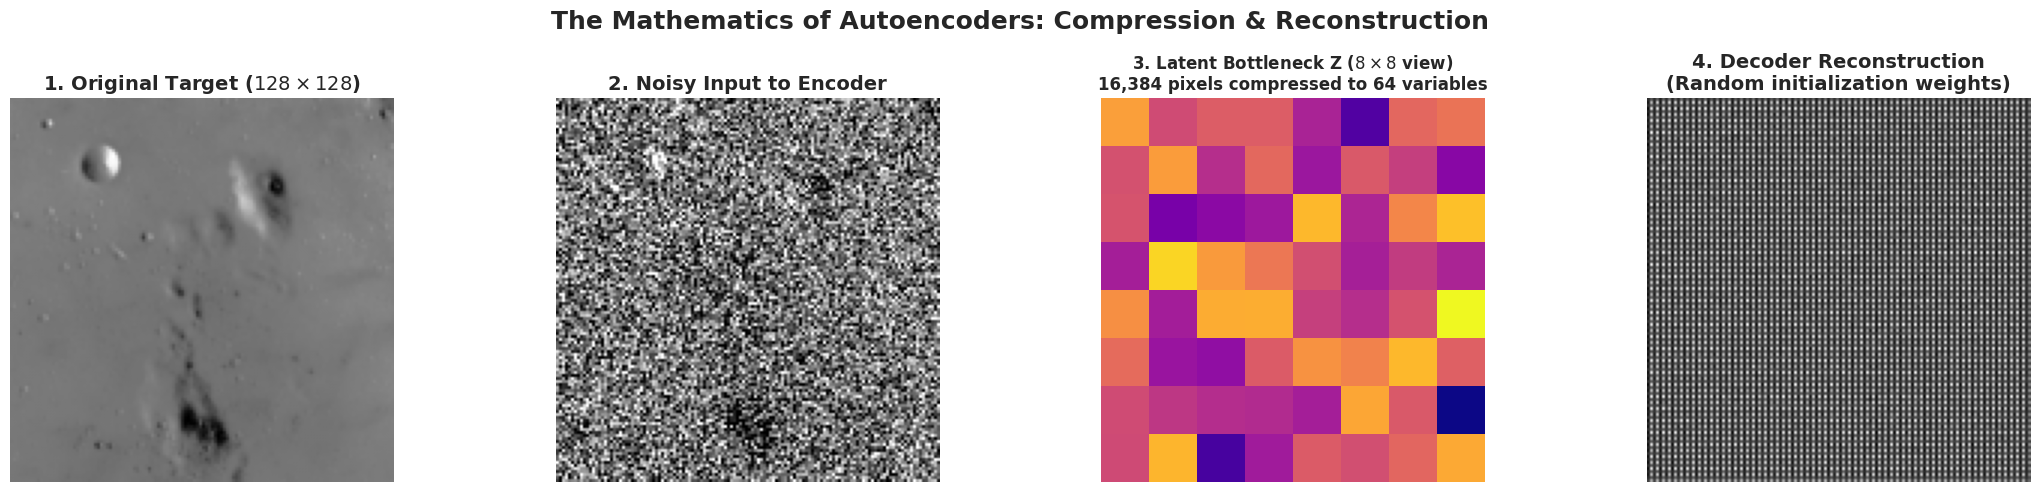


--- 💡 Architectural Insight ---
Look at Plot 3. This 8x8 matrix of colors is the physical manifestation of the Latent Space. The network has taken the complex, noisy crater geometry from Plot 2 and algorithmically squeezed it through this tiny mathematical keyhole. Because the network in this example is untrained (random weights), Plot 4 looks like an abstract blur. But if we ran Backpropagation for 50 Epochs, the network would perfectly learn to drop the noise at the keyhole, and Plot 4 would hallucinate a pristine, high-resolution copy of Plot 1 from those 64 variables alone!


In [2]:
# 1. Fetch and Preprocess the Target Image
numpy_moon = data.moon()

# We resize to 128x128 for clear mathematical downsampling
resized_moon = resize(numpy_moon, (128, 128), anti_aliasing=True)

# Convert to PyTorch Tensor: [Batch, Channels, Height, Width] -> [1, 1, 128, 128]
moon_tensor = torch.tensor(resized_moon, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
print(f"Original Input Shape: {moon_tensor.shape} (16,384 pixels)")

# 2. Inject Thermodynamic Entropy (Gaussian Noise)
# We simulate a corrupted sensor transmission by adding random noise to the clean tensor
noise = torch.randn_like(moon_tensor) * 0.3
noisy_moon_tensor = torch.clamp(moon_tensor + noise, 0.0, 1.0) # Clamp ensures pixels stay valid

# 3. Architect the Autoencoder
class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        
        # --- THE ENCODER (Compression) ---
        self.encoder = nn.Sequential(
            # [1, 128, 128] -> [16, 64, 64]
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # [16, 64, 64] -> [32, 32, 32]
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # [32, 32, 32] -> [64, 16, 16]
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        
        # --- THE BOTTLENECK (Latent Space Z) ---
        self.flatten = nn.Flatten()
        # 64 channels * 16 * 16 = 16,384 flattened features -> compressed to 'latent_dim'
        self.compress_to_z = nn.Linear(64 * 16 * 16, latent_dim)
        
        # The Inverse: Pushing Z back into spatial dimensions
        self.expand_from_z = nn.Linear(latent_dim, 64 * 16 * 16)
        self.unflatten = nn.Unflatten(1, (64, 16, 16))
        
        # --- THE DECODER (Reconstruction) ---
        self.decoder = nn.Sequential(
            # [64, 16, 16] -> [32, 32, 32]
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # [32, 32, 32] -> [16, 64, 64]
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # [16, 64, 64] -> [1, 128, 128]
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            # Sigmoid mathematically forces the final predicted pixels exactly between 0.0 and 1.0!
            nn.Sigmoid() 
        )

    def forward(self, x):
        # 1. Extract and Spatial Compression
        encoded_features = self.encoder(x)
        
        # 2. Vectorize and Bottleneck
        flat_features = self.flatten(encoded_features)
        z = self.compress_to_z(flat_features)
        
        # 3. Expand from Bottleneck
        expanded_features = self.expand_from_z(z)
        spatial_features = self.unflatten(expanded_features)
        
        # 4. Spatial Reconstruction
        reconstructed_image = self.decoder(spatial_features)
        
        return reconstructed_image, z

# 4. Execute the Deep Geometry Pipeline
print("--- 🧠 Executing the Autoencoder Pipeline ---")
# We initialize with a tiny 64-dimensional bottleneck
model = DenoisingAutoencoder(latent_dim=64)
model.eval()

with torch.no_grad():
    # Pass the NOISY moon into the network
    reconstructed_moon, latent_vector = model(noisy_moon_tensor)

print(f"Latent Vector (Z) Shape: {latent_vector.shape} (Just 64 numbers!)")
print(f"Reconstructed Shape:     {reconstructed_moon.shape}")

# 5. Visualizing the Compression Architecture
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("The Mathematics of Autoencoders: Compression & Reconstruction", fontsize=18, fontweight='bold')

# Plot A: Original Clean Target
axes[0].imshow(moon_tensor.squeeze().numpy(), cmap='gray')
axes[0].set_title("1. Original Target ($128 \\times 128$)", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot B: The Noisy Input
axes[1].imshow(noisy_moon_tensor.squeeze().numpy(), cmap='gray')
axes[1].set_title("2. Noisy Input to Encoder", fontweight='bold', fontsize=14)
axes[1].axis('off')

# Plot C: The Latent Vector Z
# We reshape the 64 numbers into an 8x8 matrix just so we can physically see them
z_visual = latent_vector.view(8, 8).numpy()
axes[2].imshow(z_visual, cmap='plasma')
axes[2].set_title("3. Latent Bottleneck Z ($8 \\times 8$ view)\n16,384 pixels compressed to 64 variables", fontweight='bold', fontsize=12)
axes[2].axis('off')

# Plot D: The Reconstructed Output (Untrained)
axes[3].imshow(reconstructed_moon.squeeze().numpy(), cmap='gray')
axes[3].set_title("4. Decoder Reconstruction\n(Random initialization weights)", fontweight='bold', fontsize=14)
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("\n--- 💡 Architectural Insight ---")
print("Look at Plot 3. This 8x8 matrix of colors is the physical manifestation of the Latent Space. The network has taken the complex, noisy crater geometry from Plot 2 and algorithmically squeezed it through this tiny mathematical keyhole. Because the network in this example is untrained (random weights), Plot 4 looks like an abstract blur. But if we ran Backpropagation for 50 Epochs, the network would perfectly learn to drop the noise at the keyhole, and Plot 4 would hallucinate a pristine, high-resolution copy of Plot 1 from those 64 variables alone!")

## Real-World Use Case or Analogy:

Think of an Autoencoder like **A Master Astronomer and a Sketch Artist working over a broken radio**:

* **The Noisy Input ($\tilde{X}$)**: The Astronomer (The Encoder) is looking at the moon through a telescope, but there is a terrible storm (Gaussian Noise).
* **The Encoder**: The Astronomer's job is to look past the storm and figure out the exact mathematical coordinates of the major craters.
* **The Latent Space ($Z$)**: The Astronomer cannot send a photograph to Earth. They only have a broken radio that allows them to transmit exactly 64 words (The Bottleneck). The Astronomer uses their deep knowledge of physics to ignore the storm clouds and transmit only the 64 most critical architectural variables (e.g., *"Large crater, coordinate 45, depth 10"*). This transmission is a massive dimensionality reduction.
* **The Decoder**: Down on Earth, a Master Sketch Artist receives those 64 words. They have never seen the storm. They sit down with a blank piece of paper and use their deep knowledge of how shadows and light work on lunar surfaces to mathematically rebuild a flawless, high-resolution drawing of the moon ($\hat{X}$). The storm (the noise) was completely filtered out because it couldn't fit through the 64-word radio transmission!